# Student name: David Sheridan

# Student ID: 24300446

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import math
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report

# Task 1a

These functions are provided to assist you in Task 1a

In [6]:
def point_on_boundary(weights, x):
    """ Return the y-position on the boundary based on given x-position.  """
    return -(weights[0]+weights[1]*x)/weights[2]

In [7]:
def decision_boundary(weights, x_min, x_max):
    """ Return two points on the decision boundary: one at x_min and one at x_max """
    return [point_on_boundary(weights, x_min), point_on_boundary(weights, x_max)]

Please add cells according to your own requirements.

In [9]:
#Function to load the dataset
def load_data(filename):
    try:
        data = np.loadtxt(filename, delimiter=",")
        return data[:, :2], data[:, 2]  # Features (X) and labels (y)
    except Exception as e:
        print(f"Error loading file: {e}")
        return None, None

In [10]:
#Function to plot the decision boundary
def plot_decision_boundary(X, y, weights, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    #Drawing the decision boundary
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    boundary_points = decision_boundary(weights, x_min, x_max)
    plt.plot([x_min, x_max], boundary_points, 'k--', label="Decision Boundary")
    plt.legend()
    plt.show()

In [11]:
#Function to train and evaluate logistic regression
def train_and_evaluate(X_train, y_train, X_test, y_test):
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Compute errors
    ein = 1 - model.score(X_train, y_train)
    eout = 1 - model.score(X_test, y_test)

    # Get weights
    weights = np.hstack([model.intercept_, model.coef_.flatten()])

    print(f"Training Error (Ein): {ein:.4f}")
    print(f"Test Error (Eout): {eout:.4f}")
    print(f"Weights: {weights}")

    return weights, eout

In [12]:
#Running Task
def run_task1a():
    X_train, y_train = load_data("Et2_Classification_TrainingData.csv")
    X_test, y_test = load_data("Et2_Classification_TestData.csv")

    if X_train is None or X_test is None:
        return

    print(f"Training Points: {len(X_train)}, Test Points: {len(X_test)}")

    weights, eout = train_and_evaluate(X_train, y_train, X_test, y_test)
    plot_decision_boundary(X_test, y_test, weights, f"Logistic Regression (Eout: {eout:.4f})")

Training Points: 70, Test Points: 30
Training Error (Ein): 0.5286
Test Error (Eout): 0.6333
Weights: [-0.10493618 -0.09026453 -0.20290918]


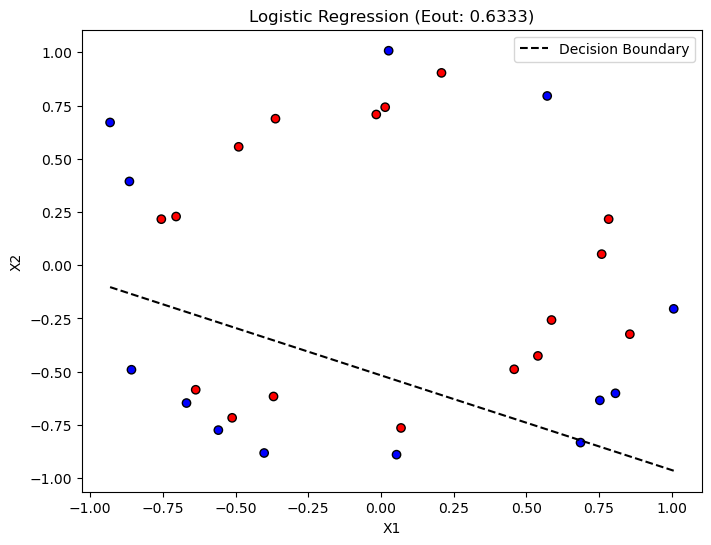

In [13]:
#Running the function
run_task1a()

## Questions:

Answer the following questions: 
- How do the found values for Ein and Eout for the various models relate to model complexity?
- Explain how data transformations can lead to linear separability of a dataset.
- Explain how data transformations effect the complexity of your model.

Your answer to these questions..

- How do the found values for Ein and Eout for the various models relate to model complexity?
As model complexity increases (adding more features), Ein (training error) tends to decrease as the model fits the training data better. However Eout (test error) does not always decrease. If the model is too complex, it may overfit the training data and perform poorly on fresh data.

- Explain how data transformations can lead to linear separability of a dataset.
Some datasets are n ot linearly seperable in their original form (e.g. circles). By applying transofrmations like squaring features, we can project the data into a new space where a straight line can seperate the classes.

- Explain how data transformations effect the complexity of your model.
Adding transformations increases model complexity by introducing new features. If done correctly, it can help the model capture patterns in the data. However, too many features can lead to overfitting, where the model memorises the training data isntead of learning general patterns.

# Task 1b

In [48]:
def weights(X,y):
    '''Returns the weight vector associated with the regression line that best describes the data X,y in an MSE fashion '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    # Calculation of weights using pseudo-inverse.
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [50]:
def linreg_predict(w,X):
    ''' Returns a prediction y for data point X for a linear regression described by weights w '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

In [52]:
def calc_error(w,X,y):
    # Calculate the error as the mean squared error
    pred = linreg_predict(w,X)
    return (pred-np.array(y)).dot(pred-np.array(y))/len(X)

In [54]:
def transPoly(X, power):
    # Extend the data in X with a bias (1) and powers of the feature up to 'power'
    extra=[]
    for x in X:
        row=[]
        for p in range(2,power+1):
            row.append(x**p)
        extra.append(row)
    return np.concatenate((X.reshape(len(X),1),np.array(extra)),1)

In [72]:
#Load dataset
data = pd.read_csv("Et2_Regression_Data.csv")
X = data.iloc[:, 0].values  # Feature
y = data.iloc[:, 1].values  # Target

To prevent results due to luck, it is useful to repeat your experiments a good few times and look at average results. The below code snippet may be useful in this regard.

In [75]:
error_in = []
error_out = []
repeats = 100
power_range = range(5,11) # it is up to you to decide on a suitable range

for power in power_range: 
    e_in=0
    e_out=0
    for r in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8) 
        X_train_trans = transPoly(X_train, power)
        X_test_trans = transPoly(X_test, power)
        w = weights(X_train_trans,y_train)
        e_in += calc_error(w,X_train_trans,y_train)
        e_out+= calc_error(w,X_test_trans,y_test)
    error_in.append(e_in/repeats)
    error_out.append(e_out/repeats)

Please add cells according to your own requirements.

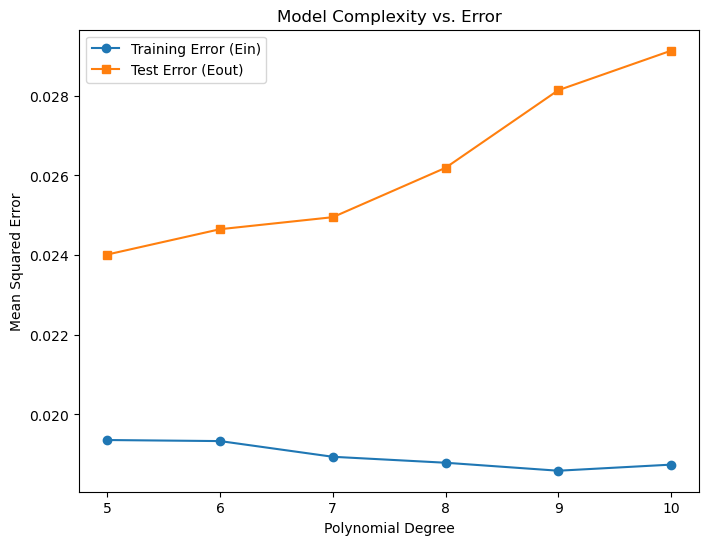

In [77]:
#Plot results
plt.figure(figsize=(8, 6))
plt.plot(power_range, error_in, label="Training Error (Ein)", marker='o')
plt.plot(power_range, error_out, label="Test Error (Eout)", marker='s')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Model Complexity vs. Error")
plt.show()

## Questions:
Answer the following questions:
- How does the plot of Ein and Eout versus degree of the used polynomial data transformation relate to model complexity?
- How can the choice of transformation that yielded the best results be explained in terms of sample complexity? 

Your answer to these questions..

- How does the plot of Ein and Eout versus degree of the used polynomial data transformation relate to model complexity?
As the polynomial degree increases, Ein (training error) decreases because the model becomes more flexible and fits the training data better. However, Eout (test error) initially decreases but then increases after a certain degree. This happens because the model starts overfitting—learning noise instead of the true pattern. The best model is found at the degree where Eout is minimised before it starts increasing again.

- How can the choice of transformation that yielded the best results be explained in terms of sample complexity?
A higher-degree polynomial model requires more data to generalise well. If there’s not enough data, the model overfits, leading to high test error. The best transformation balances model complexity and available data—capturing the pattern without overfitting. This follows the principle that more complex models need more samples to avoid overfitting.

# Task 2

Below is an implementation of linear regression with regularization

In [83]:
def weights_reg(X,y,l):
    '''Returns the weight vector associated with the regression line that best describes the data X,y in an MSE fashion 
    including a weight regularisation penalty term controlled using l '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    n = len(X)
    m=X.T.dot(X)
    return np.linalg.inv(m+l*np.identity(m.shape[0])).dot(X.T).dot(y)

In [131]:
#Feature transformation function
def transPoly(X, power):
    """Extending the data in X with a bias (1) and powers of the feature up to 'power'."""
    X = X.reshape(-1, 1)  #Ensuring X is 2D
    extra = np.hstack([X**p for p in range(2, power + 1)])  #Transforming the features
    return np.concatenate((X, extra), axis=1)  # Combining the original and transformed

In [133]:
#Error calculation function
def calc_error(w, X, y):
    """Calculates Mean Squared Error (MSE)."""
    X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)  # Add bias
    pred = X.dot(w)
    return np.mean((pred - y) ** 2)

This code snippet may be useful to keep track of Ein, Eout and the corresponding weights for various regulariser parameters

Best lambda: 0.0012328467394420659


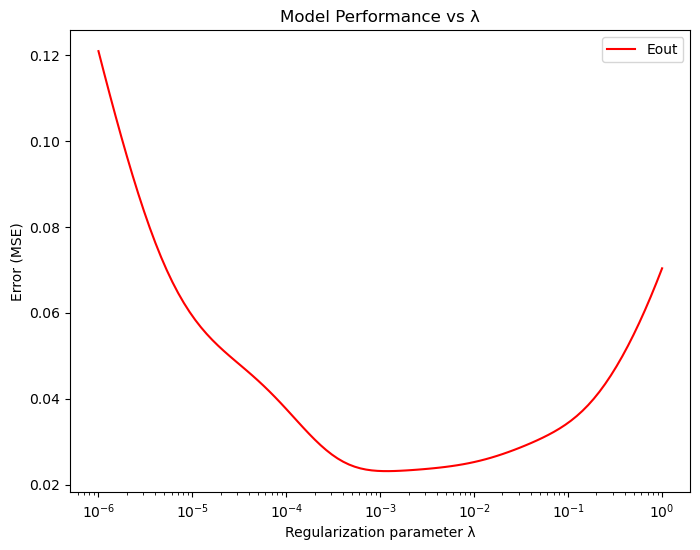

In [136]:
ein=[]
eout=[]
weights=[]
lambdas = np.logspace(-6, 0, 100) #100 values between 10⁻⁶ and 1
X_trans = transPoly(X,50)
# random_state fixed to get reproducible (and 'good'! :-)) results
X_train, X_test, y_train, y_test = train_test_split(X_trans, y, train_size=0.5, random_state =5)
for l in lambdas:    
    w = weights_reg(X_train,y_train,l)
    ein.append(calc_error(w,X_train,y_train))
    eout.append(calc_error(w,X_test,y_test))
    weights.append(w)

#Finding the best lambda (minimum Eout)
best_lambda = lambdas[np.argmin(eout)]
best_w = weights[np.argmin(eout)]
print(f"Best lambda: {best_lambda}")

#Plotting Model Performance vs λ
plt.figure(figsize=(8, 6))
plt.plot(lambdas, eout, label="Eout", color='red')
plt.xscale("log")  # Logarithmic scale for λ
plt.xlabel("Regularization parameter λ")
plt.ylabel("Error (MSE)")
plt.title("Model Performance vs λ")
plt.legend()
plt.show()

Please add cells according to your own requirements.

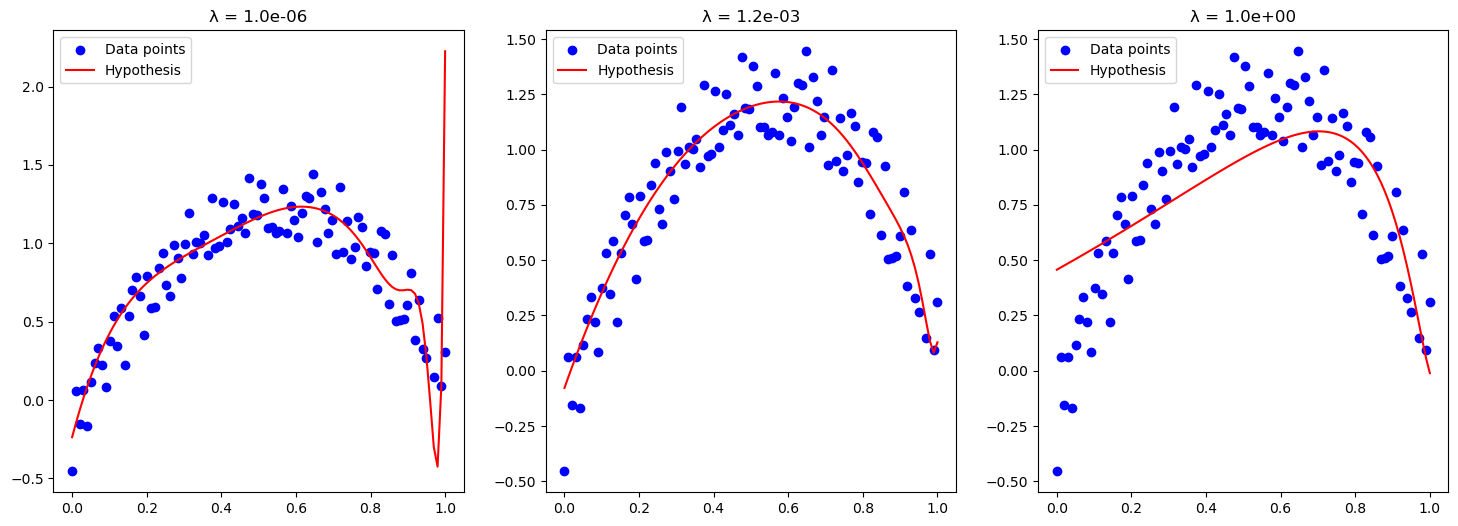

In [139]:
#Plotting overfitting, optimal, and underfitting models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
l_values = [lambdas[0], best_lambda, lambdas[-1]]  #Overfit, optimal, underfit

for i, l in enumerate(l_values):
    w = weights_reg(X_train, y_train, l)
    
    #Plotting data points
    axes[i].scatter(X, y, color="blue", label="Data points")
    
    #Plotting hypothesis
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_plot_trans = transPoly(X_plot, 50)
    y_plot = np.concatenate((np.ones((X_plot_trans.shape[0], 1)), X_plot_trans), axis=1).dot(w)
    
    axes[i].plot(X_plot, y_plot, color="red", label="Hypothesis")
    axes[i].set_title(f"λ = {l:.1e}")
    axes[i].legend()

plt.show()


## Questions

Answer the following questions:
- Interpret the information in the requested figures.
- Explain the strategy chosen to decide on the optimum amount of regularisation.
- Explain the effect of the term l*np.identity(m.shape[0]) in the pseudo-inverse.

- Interpret the information in the requested figures.
First Image (Error vs λ Plot): The curve shows that Eout decreases initially as λ increases (reducing overfitting), but then Eout increases again when λ is too large (causing underfitting). The minimum point in the curve indicates the optimal λ, minimising generalisation error.
Second Image (Three Subplots): The left plot (small λ) shows an overfitted model. The hypothesis follows the noise too closely, leading to poor generalisation. The middle plot (optimal λ) gives the best fit, balancing bias and variance. The right plot (large λ) represents an underfitted model, where excessive regularisation prevents capturing the underlying pattern in the data.

- Explain the strategy chosen to decide on the optimum amount of regularisation.
I tested different λ values and selected the one that minimises Eout (out-of-sample error). A logarithmic scale for λ was used to efficiently search across different orders of magnitude.

- Explain the effect of the term l*np.identity(m.shape[0]) in the pseudo-inverse.
It adds a penalty to large weights, helping to control overfitting. It ensures that X to the power of T by X remains invertible, preventing numerical instability. Higher λ values shrink the weights, leading to simpler models with less variance but more bias.

# Task 3

Please add cells according to your own requirements.

In [162]:
#Defining 10-Fold Cross-Validation
kf = KFold(n_splits=10, shuffle=True, random_state=5)

#Regularisation values (logarithmic scale)
lambdas = np.logspace(-6, 0, 100)

#Transforming features (raise to power 50)
X_trans = transPoly(X, 50)

In [157]:
#Initialising error lists
eval_mean = []  #Average validation error
eout = []  #Out-of-sample error
weights = []
#Performing cross-validation for each lambda
for l in lambdas:
    eval_errors = []  #Stores validation errors for each fold

    for train_idx, val_idx in kf.split(X_trans):
        X_train, X_val = X_trans[train_idx], X_trans[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        #Train model with regularization
        w = weights_reg(X_train, y_train, l)

        #Calculate validation error (Eval)
        eval_errors.append(calc_error(w, X_val, y_val))

In [158]:
#Storing the mean validation error across folds
eval_mean.append(np.mean(eval_errors))

#Train model on full training set and compute test error
w_full = weights_reg(X_trans, y, l)
eout.append(calc_error(w_full, X_trans, y))
weights.append(w_full)

In [159]:
#Finding best lambda (minimum Eval)
best_lambda = lambdas[np.argmin(eval_mean)]
best_w = weights[np.argmin(eval_mean)]
print(f"Best lambda (cross-validation): {best_lambda}")

Best lambda (cross-validation): 1e-06


ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

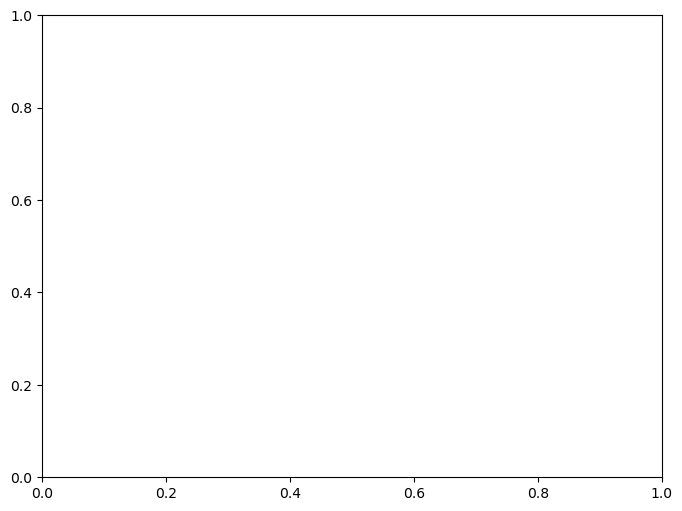

In [164]:
#Plotting model performance vs lambda
plt.figure(figsize=(8, 6))
plt.plot(lambdas, eval_mean, label="Eval (10-fold)", color='blue')
plt.plot(lambdas, eout, label="Eout", color='red', linestyle="dashed")
plt.xscale("log")
plt.xlabel("Regularization parameter λ")
plt.ylabel("Error (MSE)")
plt.title("Model Performance vs λ (10-Fold CV)")
plt.legend()
plt.show()

## Questions
- Explain the procedure followed by using KFOLDS and your choice of parameters.
The procedure using KFold cross-validation involves splitting the dataset into 10 equal parts (folds). The model is trained 9 times, each time using 9 folds for training and 1 fold for validation. This ensures every data point is used for both training and validation.
My choice of parameters:
n_splits=10: This divides the data into 10 folds for 10-fold cross-validation, which is a common choice for balancing training/validation data and model performance.
shuffle=True: Randomly shuffles the data before splitting, preventing bias from the data's order.
random_state=5: Ensures that the shuffling is reproducible, so results are consistent across runs.

## Reflection

- Provide a concise description of your code. 
- Also clearly describe the changes you have made based on your peers' work and feedback.
- Summarise your understanding of:
1. the relationship between feature transformations and model complexity.
2. how regularisation impacts the complexity of a model.
3. how complexity impacts the data requirements to successfully train a machine learning model.

Provide a concise description of your code.
1. Task 1a involves training a logistic regression model on a dataset and evaluating it on another. The model's decision boundary is plotted, and the training error (Ein) and test error (Eout) are computed. The code allows the user to experiment with feature transformations (e.g., polynomial transformations) to improve model performance.
2. Task 1b explores the process of fitting a linear regression model to noisy data and performing feature transformations to optimise model performance. Polynomial transformations are applied, and the model is trained and evaluated using the Mean Squared Error (MSE) metric on both training and test datasets. The relationship between polynomial degree and model error is analysed.
3. Task 2 involves using regularisation in a linear regression model. The code applies a regularisation parameter (lambda) to control model complexity and avoid overfitting. The optimal lambda is found through cross-validation, and the model's performance is compared for different values of lambda.
4. Task 3 extends Task 2 by introducing 10-fold cross-validation to evaluate model performance more robustly and optimise the regularisation parameter using the Kfold method from scikit-learn.

Also clearly describe the changes you have made based on your peers' work and feedback.

Summarise your understanding of:
the relationship between feature transformations and model complexity.
Feature transformations can significantly increase the complexity of a model. For example, applying polynomial transformations to a dataset adds new features that represent higher-order terms, allowing the model to capture more complex relationships in the data. However, increasing the degree of the polynomial can make the model more flexible and prone to overfitting, particularly if the data is noisy or sparse. Linear separability can also be improved with transformations, as higher-order features can help separate non-linearly separable data points in higher-dimensional spaces. For instance, applying polynomial transformations in logistic regression can improve the model's ability to classify non-linearly separable data by mapping the data to a higher-dimensional feature space.

how regularisation impacts the complexity of a model.
Regularisation introduces a penalty term into the model’s cost function to prevent overfitting. It helps reduce model complexity by discouraging overly large weights. The regularisation parameter (lambda) controls the strength of this penalty. If the lambda is too small, the model may overfit the training data, resulting in a high variance and poor generalisation to new data (high Eout). On the other hand, a large lambda can lead to underfitting by excessively penalizing the weights, causing the model to miss important patterns in the data. Regularisation strikes a balance between fitting the training data well and maintaining the model’s ability to generalise to new data.

how complexity impacts the data requirements to successfully train a machine learning model.
Higher model complexity (e.g., adding more features or using more flexible models like higher-degree polynomials or deep neural networks) requires more data to train effectively. Without sufficient data, a complex model is more likely to overfit, memorising noise instead of learning meaningful patterns. In contrast, simpler models (e.g., linear regression with few features) may perform well with smaller datasets but may struggle to capture complex patterns in the data. However, with enough data, even simple models can generalise well. As model complexity increases, the data must be representative and large enough to avoid overfitting and to ensure the model can effectively learn the true underlying patterns in the data.